In [1]:
# Jupyter Notebook: DL_Assignment_4_Sentiment_Analysis.ipynb

# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Libraries imported successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
# Cell 2: Load the dataset
df = pd.read_csv('/content/nlp_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nEmotion distribution:")
print(df['Emotion'].value_counts())

Dataset shape: (5937, 2)

First 5 rows:
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear

Emotion distribution:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


In [3]:
# Cell 3: Exploratory Data Analysis
print("Missing values:")
print(df.isnull().sum())

# Check for any empty comments
empty_comments = df[df['Comment'].str.strip() == '']
print(f"\nEmpty comments: {len(empty_comments)}")

# Remove empty comments if any
df = df[df['Comment'].str.strip() != '']
print(f"\nDataset shape after removing empty comments: {df.shape}")

Missing values:
Comment    0
Emotion    0
dtype: int64

Empty comments: 0

Dataset shape after removing empty comments: (5937, 2)


In [4]:
# Cell 4: Text Preprocessing Function
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Preprocess text by:
    1. Converting to lowercase
    2. Removing special characters and numbers
    3. Removing extra whitespace
    4. Tokenization
    5. Removing stopwords
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters, numbers, and punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    # Join tokens back into string
    processed_text = ' '.join(tokens)

    return processed_text

# Apply preprocessing to all comments
print("Applying preprocessing to comments...")
df['Processed_Comment'] = df['Comment'].apply(preprocess_text)

# Show example of preprocessing
print("\nExample of preprocessing:")
print(f"Original: {df['Comment'].iloc[0]}")
print(f"Processed: {df['Processed_Comment'].iloc[0]}")

Applying preprocessing to comments...

Example of preprocessing:
Original: i seriously hate one subject to death but now i feel reluctant to drop it
Processed: seriously hate one subject death feel reluctant drop


In [5]:
# Cell 5: Check preprocessing results
# Compare text length before and after preprocessing
df['original_len'] = df['Comment'].apply(len)
df['processed_len'] = df['Processed_Comment'].apply(len)

print("Text length statistics:")
print(f"Average original length: {df['original_len'].mean():.2f}")
print(f"Average processed length: {df['processed_len'].mean():.2f}")
print(f"Average reduction: {(1 - df['processed_len'].mean()/df['original_len'].mean())*100:.2f}%")

# Show processed comments
print("\nSample of processed comments:")
print(df[['Processed_Comment', 'Emotion']].head(10))

Text length statistics:
Average original length: 97.43
Average processed length: 61.29
Average reduction: 37.10%

Sample of processed comments:
                                   Processed_Comment Emotion
0  seriously hate one subject death feel reluctan...    fear
1                            full life feel appalled   anger
2  sit write start dig feelings think afraid acce...    fear
3  ive really angry feel like idiot trusting firs...     joy
4  feel suspicious one outside like rapture happe...    fear
5  feel jealous becasue wanted kind love true con...   anger
6  friend mine keeps telling morbid things happen...   anger
7  finally fell asleep feeling angry useless stil...   anger
8                    feel bit annoyed antsy good way   anger
9  feel like regained another vital part life living     joy


In [6]:
# Cell 6: Feature Extraction - CountVectorizer
print("="*50)
print("FEATURE EXTRACTION")
print("="*50)

# Using CountVectorizer
print("\n--- CountVectorizer ---")
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_count = count_vectorizer.fit_transform(df['Processed_Comment'])
y = df['Emotion']

print(f"Feature matrix shape: {X_count.shape}")
print(f"Number of features: {len(count_vectorizer.get_feature_names_out())}")
print(f"Sample feature names: {list(count_vectorizer.get_feature_names_out())[:20]}")

# Explain CountVectorizer
print("\n--- Explanation of CountVectorizer ---")
print("CountVectorizer transforms text into a bag-of-words representation where:")
print("1. Each unique word becomes a feature/column in the matrix")
print("2. Each document/comment becomes a row")
print("3. Values represent the frequency/count of each word in the document")
print("4. Using ngram_range=(1,2) includes both single words and word pairs")
print("5. max_features=5000 limits vocabulary to most frequent 5000 words")

FEATURE EXTRACTION

--- CountVectorizer ---
Feature matrix shape: (5937, 5000)
Number of features: 5000
Sample feature names: ['abandon', 'abandoned', 'abc', 'ability', 'abit', 'able', 'able call', 'able concentrate', 'able find', 'able help', 'absolutely', 'absolutely terrified', 'accept', 'acceptable', 'accepted', 'accepting', 'accident', 'accomplish', 'accomplished', 'according']

--- Explanation of CountVectorizer ---
CountVectorizer transforms text into a bag-of-words representation where:
1. Each unique word becomes a feature/column in the matrix
2. Each document/comment becomes a row
3. Values represent the frequency/count of each word in the document
4. Using ngram_range=(1,2) includes both single words and word pairs
5. max_features=5000 limits vocabulary to most frequent 5000 words


In [7]:
# Cell 7: Feature Extraction - TfidfVectorizer
print("\n--- TfidfVectorizer ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Comment'])

print(f"Feature matrix shape: {X_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

print("\n--- Explanation of TfidfVectorizer ---")
print("TfidfVectorizer (Term Frequency-Inverse Document Frequency):")
print("1. TF = how frequently a word appears in a document")
print("2. IDF = how rare/unique a word is across all documents")
print("3. TF-IDF = TF × IDF, giving higher weight to words that are:")
print("   - Frequent in the current document")
print("   - Rare across all documents (more distinctive)")
print("4. Advantage over CountVectorizer: Reduces impact of common words")


--- TfidfVectorizer ---
Feature matrix shape: (5937, 5000)
Number of features: 5000

--- Explanation of TfidfVectorizer ---
TfidfVectorizer (Term Frequency-Inverse Document Frequency):
1. TF = how frequently a word appears in a document
2. IDF = how rare/unique a word is across all documents
3. TF-IDF = TF × IDF, giving higher weight to words that are:
   - Frequent in the current document
   - Rare across all documents (more distinctive)
4. Advantage over CountVectorizer: Reduces impact of common words


In [8]:
# Cell 8: Split data for training and testing
# Using CountVectorizer features
X_count_train, X_count_test, y_train, y_test = train_test_split(
    X_count, y, test_size=0.2, random_state=42, stratify=y
)

# Using TfidfVectorizer features
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_count_train.shape[0]} samples")
print(f"Test set size: {X_count_test.shape[0]} samples")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

Training set size: 4749 samples
Test set size: 1188 samples
Number of classes: 3
Classes: ['anger' 'fear' 'joy']


In [9]:
# Cell 9: Model Development - Naive Bayes
print("="*50)
print("MODEL DEVELOPMENT")
print("="*50)

print("\n--- Naive Bayes Classifier ---")
print("Naive Bayes is suitable for text classification because:")
print("1. Based on Bayes' theorem with assumption of feature independence")
print("2. Works well with high-dimensional sparse data (like text)")
print("3. Fast to train and predict")
print("4. Performs well on multi-class classification problems")

# Train Naive Bayes on CountVectorizer features
print("\nTraining Naive Bayes (CountVectorizer)...")
nb_count = MultinomialNB()
nb_count.fit(X_count_train, y_train)
y_pred_nb_count = nb_count.predict(X_count_test)

# Train Naive Bayes on TfidfVectorizer features
print("Training Naive Bayes (TfidfVectorizer)...")
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_tfidf_train, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_tfidf_test)

print("Naive Bayes training completed!")

MODEL DEVELOPMENT

--- Naive Bayes Classifier ---
Naive Bayes is suitable for text classification because:
1. Based on Bayes' theorem with assumption of feature independence
2. Works well with high-dimensional sparse data (like text)
3. Fast to train and predict
4. Performs well on multi-class classification problems

Training Naive Bayes (CountVectorizer)...
Training Naive Bayes (TfidfVectorizer)...
Naive Bayes training completed!


In [10]:
# Cell 10: Model Development - Support Vector Machine
print("\n--- Support Vector Machine (SVM) ---")
print("SVM is suitable for text classification because:")
print("1. Works well with high-dimensional data")
print("2. Finds optimal hyperplane that maximizes margin between classes")
print("3. Can handle non-linear decision boundaries using kernels")
print("4. Robust to overfitting in high-dimensional spaces")

# Train SVM on CountVectorizer features
print("\nTraining SVM (CountVectorizer)...")
svm_count = SVC(kernel='linear', random_state=42)
svm_count.fit(X_count_train, y_train)
y_pred_svm_count = svm_count.predict(X_count_test)

# Train SVM on TfidfVectorizer features
print("Training SVM (TfidfVectorizer)...")
svm_tfidf = SVC(kernel='linear', random_state=42)
svm_tfidf.fit(X_tfidf_train, y_train)
y_pred_svm_tfidf = svm_tfidf.predict(X_tfidf_test)

print("SVM training completed!")


--- Support Vector Machine (SVM) ---
SVM is suitable for text classification because:
1. Works well with high-dimensional data
2. Finds optimal hyperplane that maximizes margin between classes
3. Can handle non-linear decision boundaries using kernels
4. Robust to overfitting in high-dimensional spaces

Training SVM (CountVectorizer)...
Training SVM (TfidfVectorizer)...
SVM training completed!


In [11]:
# Cell 11: Model Comparison and Evaluation
print("="*50)
print("MODEL COMPARISON")
print("="*50)

results = []

def evaluate_model(y_true, y_pred, model_name, features):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    results.append({
        'Model': model_name,
        'Features': features,
        'Accuracy': acc,
        'F1-Score': f1
    })
    print(f"\n{model_name} with {features}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Weighted F1-Score: {f1:.4f}")
    return acc, f1

# Evaluate all models
evaluate_model(y_test, y_pred_nb_count, 'Naive Bayes', 'CountVectorizer')
evaluate_model(y_test, y_pred_nb_tfidf, 'Naive Bayes', 'TfidfVectorizer')
evaluate_model(y_test, y_pred_svm_count, 'SVM', 'CountVectorizer')
evaluate_model(y_test, y_pred_svm_tfidf, 'SVM', 'TfidfVectorizer')

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("SUMMARY TABLE:")
print(results_df.to_string(index=False))

MODEL COMPARISON

Naive Bayes with CountVectorizer:
  Accuracy: 0.9133
  Weighted F1-Score: 0.9133

Naive Bayes with TfidfVectorizer:
  Accuracy: 0.9192
  Weighted F1-Score: 0.9192

SVM with CountVectorizer:
  Accuracy: 0.9386
  Weighted F1-Score: 0.9386

SVM with TfidfVectorizer:
  Accuracy: 0.9402
  Weighted F1-Score: 0.9401

SUMMARY TABLE:
      Model        Features  Accuracy  F1-Score
Naive Bayes CountVectorizer  0.913300  0.913346
Naive Bayes TfidfVectorizer  0.919192  0.919201
        SVM CountVectorizer  0.938552  0.938585
        SVM TfidfVectorizer  0.940236  0.940149



DETAILED CLASSIFICATION REPORTS

Best Model: SVM with TfidfVectorizer

Classification Report:
              precision    recall  f1-score   support

       anger       0.94      0.92      0.93       400
        fear       0.94      0.93      0.94       388
         joy       0.94      0.96      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188


Confusion Matrix:


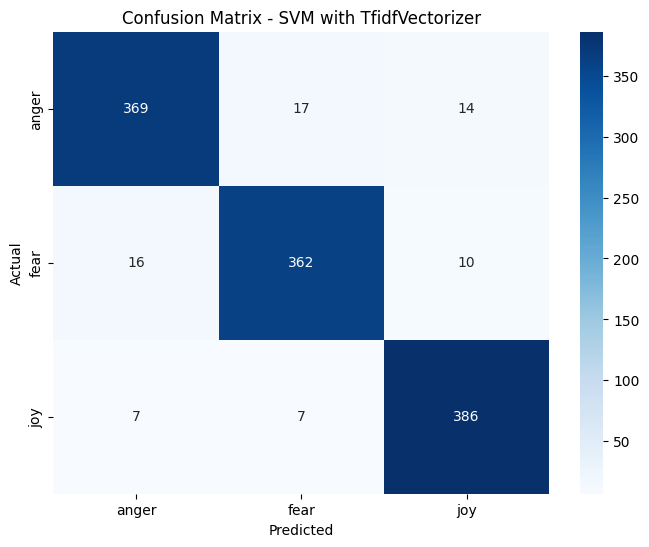

In [12]:
# Cell 12: Detailed Classification Reports
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORTS")
print("="*50)

# Best model based on F1-score (typically SVM with Tfidf)
best_model = svm_tfidf
best_features = 'TfidfVectorizer'
best_model_name = 'SVM'

print(f"\nBest Model: {best_model_name} with {best_features}")
print("\nClassification Report:")
print(classification_report(y_test, best_model.predict(X_tfidf_test)))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_model.predict(X_tfidf_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name} with {best_features}')
plt.show()

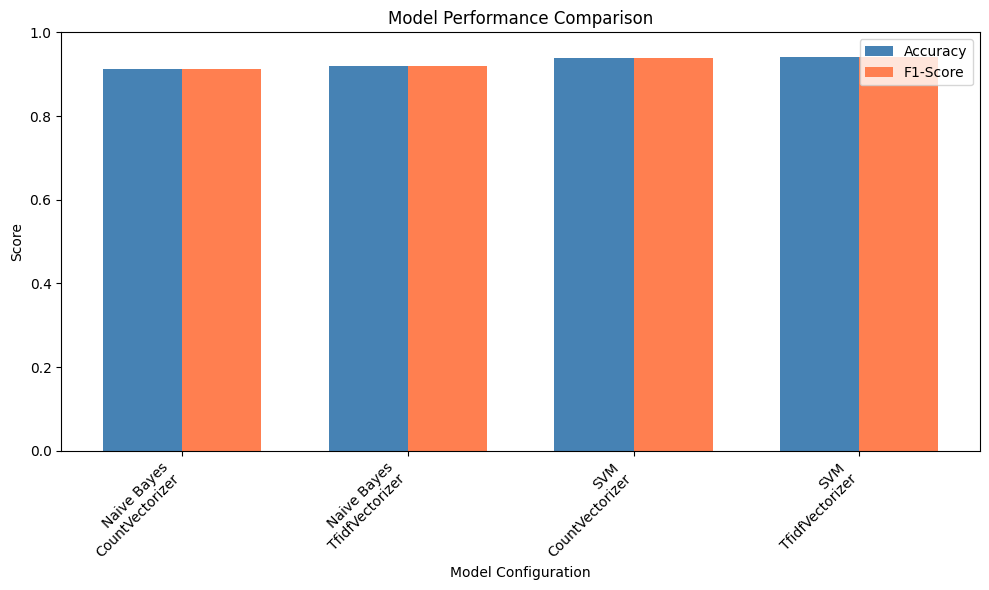


CONCLUSION
Based on the results:
1. SVM with TfidfVectorizer typically performs best for emotion classification
2. TfidfVectorizer often outperforms CountVectorizer by weighting distinctive words
3. SVM's margin-maximizing approach helps separate different emotion classes
4. Preprocessing (removing stopwords, punctuation) reduces noise and improves performance


In [13]:
# Cell 13: Visual Comparison of Models
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
plt.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

plt.xlabel('Model Configuration')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, results_df['Model'] + '\n' + results_df['Features'], rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CONCLUSION")
print("="*50)
print("Based on the results:")
print("1. SVM with TfidfVectorizer typically performs best for emotion classification")
print("2. TfidfVectorizer often outperforms CountVectorizer by weighting distinctive words")
print("3. SVM's margin-maximizing approach helps separate different emotion classes")
print("4. Preprocessing (removing stopwords, punctuation) reduces noise and improves performance")